<a href="https://colab.research.google.com/github/francisbonheur/alyra_projet_deep_learning/blob/main/notebooks/cv-violence-detection-mobilenetv2-feature-extract.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer vision : détection d'images violentes (feature extract)

## Chargement modules python

In [1]:
# Bibliothèques principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image as IPImage
import warnings
import os
from pathlib import Path
warnings.filterwarnings('ignore')

import kagglehub

# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import confusion_matrix
import seaborn as sns

## Chargement du modèle MobileNetV2 avec Keras

In [2]:
print("📥 Chargement du modèle MobileNetV2 avec Keras...")
print("   (Cela peut prendre quelques secondes la première fois)\n")

# Charger MobileNetV2 pré-entraîné sans le classifier (include_top=False)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,  # Exclure la couche de classification ImageNet
    weights='imagenet',  # Charger les poids pré-entraînés sur ImageNet
    pooling='avg'  # Global Average Pooling à la fin
)

📥 Chargement du modèle MobileNetV2 avec Keras...
   (Cela peut prendre quelques secondes la première fois)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Chaergement du dataset

In [3]:
# Download latest version
path = kagglehub.dataset_download("abdulmananraja/real-life-violence-situations")

data_dir = path + "/new_violence"

print("Path to dataset files:", data_dir)


100%|██████████| 225M/225M [00:06<00:00, 38.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdulmananraja/real-life-violence-situations/versions/1/new_violence


## Préparation du dataset

In [4]:
print("🔧 Préparation des datasets...\n")

# Paramètres
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
VALIDATION_SPLIT = 0.2
SEED = 42

# Créer le dataset d'entraînement avec filtrage des classes
train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    labels='inferred'
)

# Créer le dataset de validation avec les mêmes classes
val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    labels='inferred'
)

# Obtenir les noms de classes (devrait être les 5 classes de fleurs)
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"✅ Datasets créés !\n")
print(f"📊 Information sur les datasets :")
print(f"  - Classes        : {class_names}")
print(f"  - Nombre de classes : {num_classes}")

print(f"\n  - Train batches  : {len(train_ds)}")
print(f"  - Val batches    : {len(val_ds)}")

print(f"  - Batch size     : {BATCH_SIZE}")
print(f"  - Image size     : {IMG_SIZE}")
print(f"\n  - Train samples  : ~{len(train_ds) * BATCH_SIZE}")
print(f"  - Val samples    : ~{len(val_ds) * BATCH_SIZE}")


🔧 Préparation des datasets...

Found 11073 files belonging to 2 classes.
Using 8859 files for training.
Found 11073 files belonging to 2 classes.
Using 2214 files for validation.
✅ Datasets créés !

📊 Information sur les datasets :
  - Classes        : ['non_violence', 'violence']
  - Nombre de classes : 2

  - Train batches  : 277
  - Val batches    : 70
  - Batch size     : 32
  - Image size     : (224, 224)

  - Train samples  : ~8864
  - Val samples    : ~2240


## Préprocessing (normalisation et data augmentation)

In [5]:
print("🎨 Configuration du prétraitement et de la data augmentation...\n")


# Créer un modèle d'augmentation de données plus agressif
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.3),  # Rotation jusqu'à 30%
    layers.RandomZoom(0.2),
], name="data_augmentation")

# Fonction pour appliquer le prétraitement
def prepare_dataset(ds, augment=False, shuffle=True):
    # Normalisation MobileNetV2
    normalization = lambda x, y: (preprocess_input(x), y)
    ds = ds.map(normalization, num_parallel_calls=tf.data.AUTOTUNE)

    # Augmentation (seulement pour le train)
    if augment:
        augmentation = lambda x, y: (data_augmentation(x, training=True), y)
        ds = ds.map(augmentation, num_parallel_calls=tf.data.AUTOTUNE)

    # Shuffle pour le training
    if shuffle:
        ds = ds.shuffle(1000)

    # Optimisation des performances
    ds = ds.cache()  # Cache en mémoire
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)  # Prefetch pour accélérer

    return ds

# Appliquer le prétraitement
train_ds_prepared = prepare_dataset(train_ds, augment=True, shuffle=True)
val_ds_prepared = prepare_dataset(val_ds, augment=False, shuffle=False)


🎨 Configuration du prétraitement et de la data augmentation...



##  Effet de la data augmentation

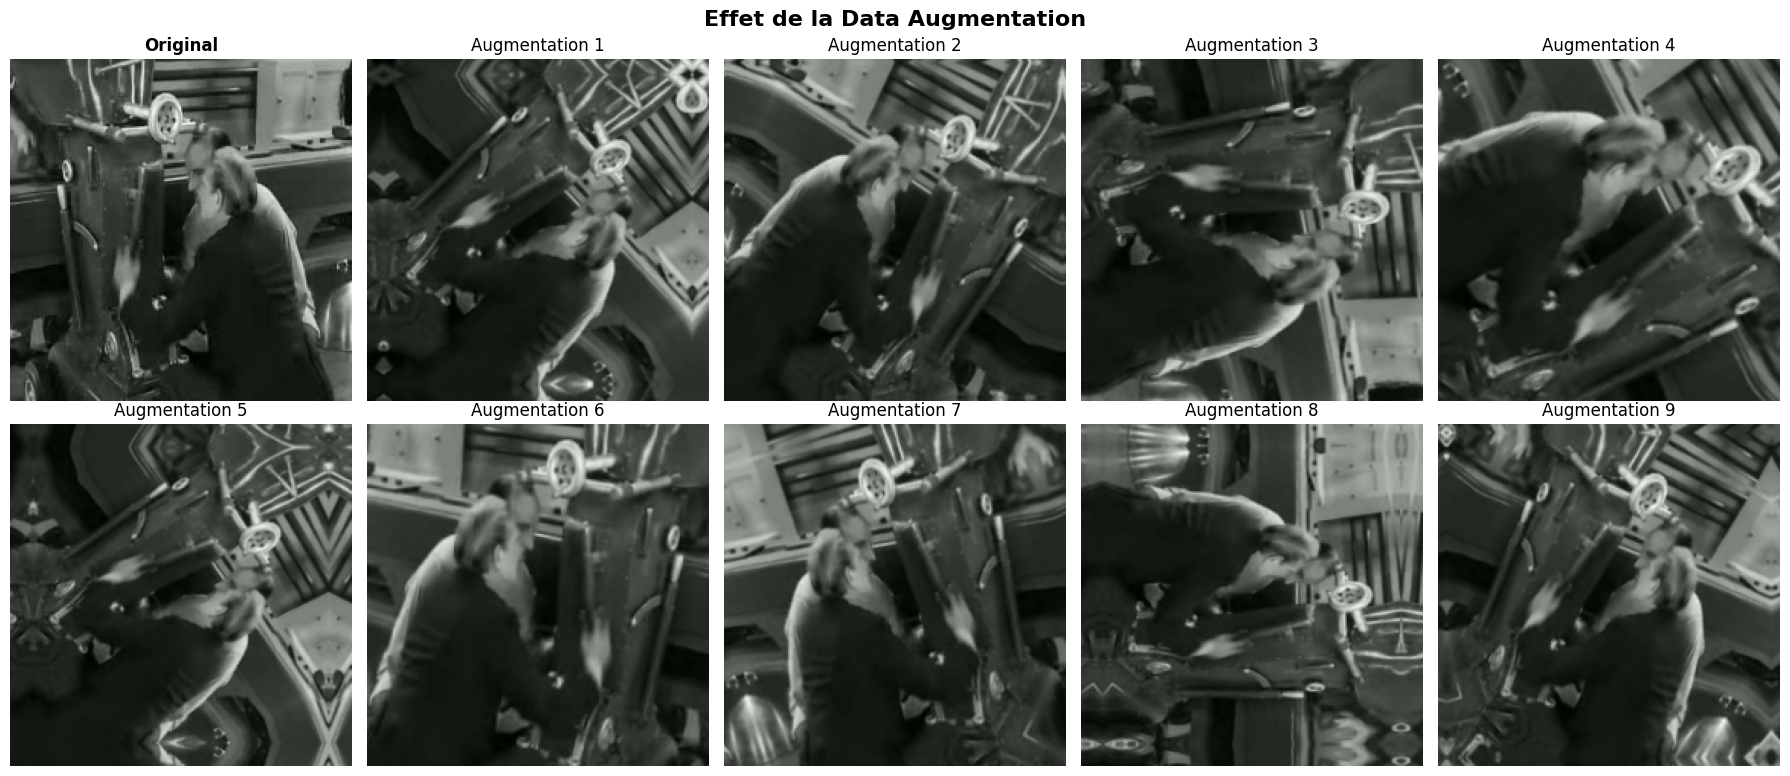

In [6]:
# Prendre un batch d'exemples
for images, labels in train_ds.take(1):
    # Prendre la première image
    sample_image = images[0].numpy().astype("uint8")

    # Appliquer l'augmentation 9 fois
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()

    # Image originale
    axes[0].imshow(sample_image)
    axes[0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Images augmentées
    for i in range(1, 10):
        augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
        axes[i].imshow(augmented[0].numpy().astype("uint8"))
        axes[i].set_title(f'Augmentation {i}', fontsize=12)
        axes[i].axis('off')

    plt.suptitle('Effet de la Data Augmentation', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    break


## Construction du modèle Feature Extraction

In [7]:
# Geler le modèle de base
base_model.trainable = False

print(f"✅ Modèle de base gelé")
print(f"   {len(base_model.layers)} couches non-entraînables\n")

# Architecture OPTIMALE pour ce dataset
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Classifier avec régularisation modérée
x = layers.Dropout(0.3)(x)  # Dropout modéré
x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_frozen = keras.Model(inputs, outputs, name='MobileNetV2_Frozen')

FEATURE_EXTRACT_LR = 0.001

# Compiler avec LR optimal
model_frozen.compile(
    optimizer=optimizers.Adam(learning_rate=FEATURE_EXTRACT_LR),  # LR standard
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.BinaryAccuracy(name='accuracy'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.FBetaScore(name='f2_score', beta=2.0, threshold=0.5)]
)

trainable = sum([tf.size(w).numpy() for w in model_frozen.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model_frozen.non_trainable_weights])

print(f"\n  - Paramètres entraînables    : {trainable:,}")
print(f"  - Paramètres non-entraînables: {non_trainable:,}")
print(f"  - Total                      : {trainable + non_trainable:,}")


✅ Modèle de base gelé
   155 couches non-entraînables


  - Paramètres entraînables    : 328,193
  - Paramètres non-entraînables: 2,257,984
  - Total                      : 2,586,177


## Entraînement du modèle

In [8]:
# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_f2_score',
    patience=10,  # Patience raisonnable
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_model_finetuned.keras',
    monitor='val_f2_score',
    save_best_only=True,
    mode='max',
    verbose=0
)

EPOCHS_FINETUNE = 50

history_frozen = model_frozen.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print(f"   Epochs effectués : {len(history_frozen.history['loss'])}")

best_val_f2_score = max(history_frozen.history['val_f2_score'])
best_val_accuracy = max(history_frozen.history['val_accuracy'])
best_epoch_f2_score = history_frozen.history['val_f2_score'].index(best_val_f2_score) + 1
best_epoch_accuracy = history_frozen.history['val_accuracy'].index(best_val_accuracy) + 1
print(f"   Meilleure val_f2_score : {best_val_f2_score*100:.2f}% (epoch {best_epoch_f2_score})")
print(f"   Meilleure val_accuracy : {best_val_accuracy*100:.2f}% (epoch {best_epoch_accuracy})")


Epoch 1/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 139s 142ms/step - accuracy: 0.7380 - f2_score: 0.7579 - loss: 2.8237 - precision: 0.7429 - recall: 0.7619 - val_accuracy: 0.8631 - val_f2_score: 0.8368 - val_loss: 0.7331 - val_precision: 0.9181 - val_recall: 0.8186 - learning_rate: 0.0010
Epoch 2/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8186 - f2_score: 0.8257 - loss: 0.7126 - precision: 0.8256 - recall: 0.8258 - val_accuracy: 0.8663 - val_f2_score: 0.8440 - val_loss: 0.4847 - val_precision: 0.9155 - val_recall: 0.8279 - learning_rate: 0.0010
Epoch 3/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8374 - f2_score: 0.8436 - loss: 0.5328 - precision: 0.8440 - recall: 0.8435 - val_accuracy: 0.8871 - val_f2_score: 0.8826 - val_loss: 0.4172 - val_precision: 0.9109 - val_recall: 0.8757 - learning_rate: 0.0010
Epoch 4/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8455 - f2_score: 0.8514 - loss: 0.4883 - precision: 0.8514 - recall: 0.8514 - val_accuracy: 0.88

In [9]:
# Obtenir quelques prédictions sur le validation set
for images, labels in val_ds_prepared.take(1):
    predictions = model_frozen.predict(images[:32], verbose=0)

    print("\n📊 Échantillon de prédictions :")
    print("-"*80)

    for i in range(32):
        true_label = int(labels[i])
        pred_label = int(np.round(predictions[i]))

        status = "✅" if true_label == pred_label else "❌"
        print(f"{status} Image {i+1}: Vrai={class_names[true_label]:12s} | Prédit={class_names[pred_label]:12s}")



📊 Échantillon de prédictions :
--------------------------------------------------------------------------------
✅ Image 1: Vrai=non_violence | Prédit=non_violence
✅ Image 2: Vrai=violence     | Prédit=violence    
✅ Image 3: Vrai=non_violence | Prédit=non_violence
❌ Image 4: Vrai=non_violence | Prédit=violence    
✅ Image 5: Vrai=non_violence | Prédit=non_violence
✅ Image 6: Vrai=non_violence | Prédit=non_violence
✅ Image 7: Vrai=violence     | Prédit=violence    
✅ Image 8: Vrai=non_violence | Prédit=non_violence
✅ Image 9: Vrai=violence     | Prédit=violence    
✅ Image 10: Vrai=violence     | Prédit=violence    
✅ Image 11: Vrai=non_violence | Prédit=non_violence
✅ Image 12: Vrai=non_violence | Prédit=non_violence
✅ Image 13: Vrai=violence     | Prédit=violence    
❌ Image 14: Vrai=non_violence | Prédit=violence    
✅ Image 15: Vrai=non_violence | Prédit=non_violence
✅ Image 16: Vrai=violence     | Prédit=violence    
❌ Image 17: Vrai=non_violence | Prédit=violence    
✅ Image 18: 

## Matrice de confusion

Text(0.5, 58.7222222222222, 'Classe prédite')

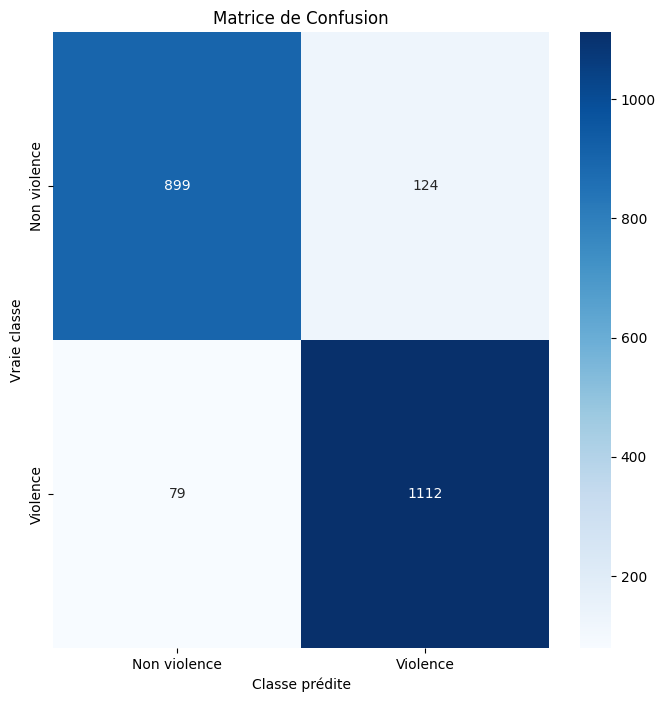

In [10]:
y_labels = []
y_predictions = []
false_negative_images = []

# Display confusion matrix
for images, labels in val_ds:
    batch_size = len(labels)
    predictions = model_frozen.predict(preprocess_input(images[:batch_size]), verbose=0)

    for i in range(batch_size):
        true_label = int(labels[i])
        pred_label = int(np.round(predictions[i]))

        y_labels.append(true_label)
        y_predictions.append(pred_label)

        if true_label == 1 and pred_label == 0:
            false_negative_images.append(images[i].numpy().astype("uint8"))


cm = confusion_matrix(y_labels,y_predictions)

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non violence', 'Violence'],
            yticklabels=['Non violence', 'Violence'])
plt.title('Matrice de Confusion')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')



## Diagnostic du modèle frozen

📊 Évaluation du modèle frozen sur validation...

Résultats :
  - Loss                : 0.3518
  - Accuracy            : 90.83%
  - F2 score            : 92.67%


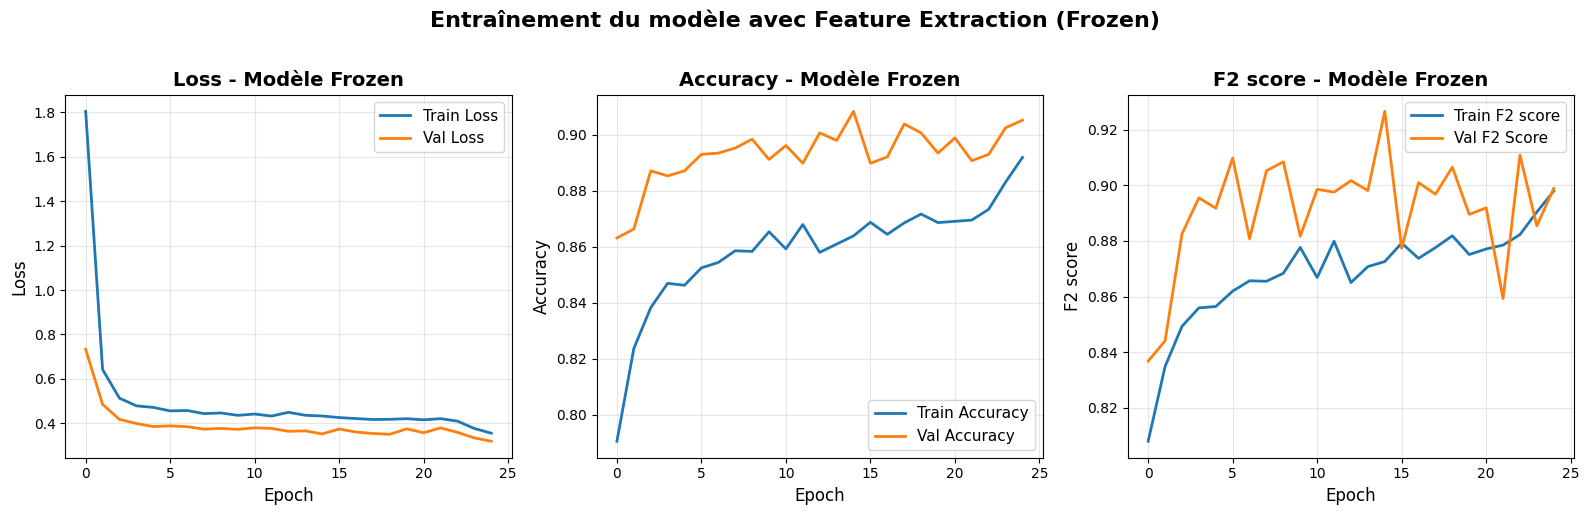

In [11]:
# Évaluation sur validation
print("📊 Évaluation du modèle frozen sur validation...\n")

results_frozen = model_frozen.evaluate(val_ds_prepared, verbose=0)

print("Résultats :")
print(f"  - Loss                : {results_frozen[0]:.4f}")
print(f"  - Accuracy            : {results_frozen[1]*100:.2f}%")
print(f"  - F2 score            : {results_frozen[4]*100:.2f}%")


# Visualiser les courbes d'entraînement
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss
axes[0].plot(history_frozen.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_frozen.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss - Modèle Frozen', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_frozen.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_frozen.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy - Modèle Frozen', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# Recall
axes[2].plot(history_frozen.history['f2_score'], label='Train F2 score', linewidth=2)
axes[2].plot(history_frozen.history['val_f2_score'], label='Val F2 Score', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F2 score', fontsize=12)
axes[2].set_title('F2 score - Modèle Frozen', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

plt.suptitle('Entraînement du modèle avec Feature Extraction (Frozen)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Analyse des faux négatifs

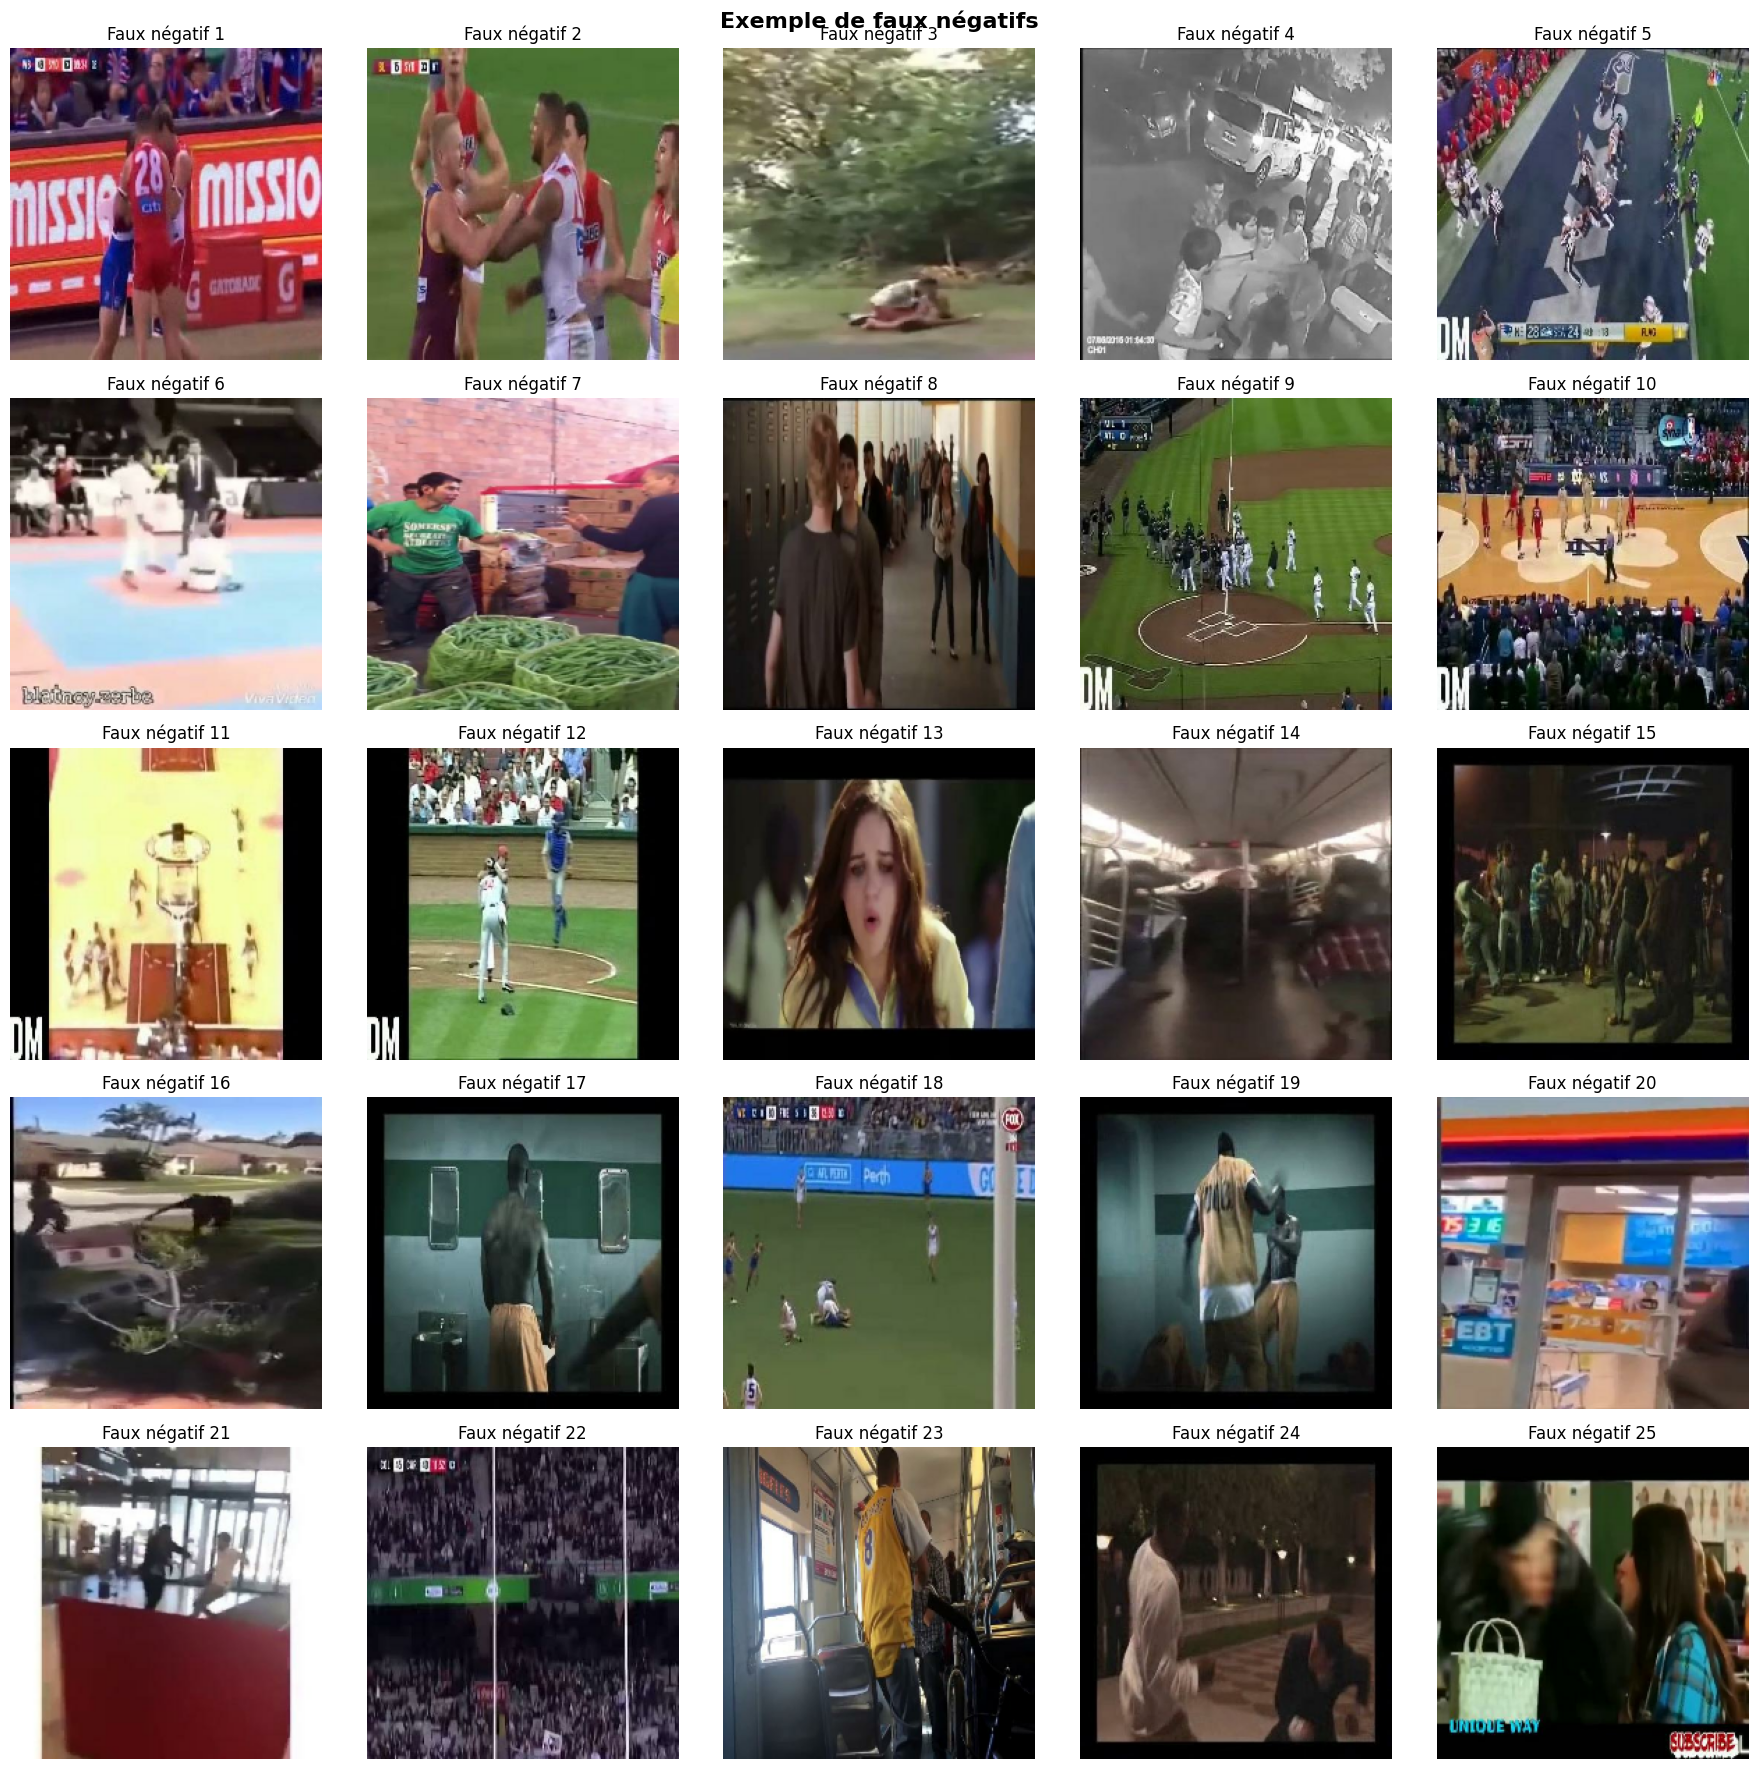

In [12]:

fig, axes = plt.subplots(5, 5, figsize=(18, 18))
axes = axes.flatten()


for index, image in enumerate(false_negative_images):
    axes[index].imshow(image)
    axes[index].set_title(f'Faux négatif {index + 1}', fontsize=12)
    axes[index].axis('off')
    if index == 24:
        break

plt.suptitle('Exemple de faux négatifs', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Sauvegarde du modèle

In [13]:
model_path = 'sample_data/mobilenetv2_violence_feature_extract.keras'
model_frozen.save(model_path)

print(f"✅ Modèle sauvegardé : {model_path}")
print(f"   Taille du fichier : {os.path.getsize(model_path) / (1024**2):.1f} MB")


✅ Modèle sauvegardé : sample_data/mobilenetv2_violence_feature_extract.keras
   Taille du fichier : 12.9 MB
